# Feature Selection Techniques in Heart Disease Prediction

## Cilj projekta

Glavni cilj ovog istraživanja je demonstracija i komparativna analiza različitih tehnika izbora atributa (Feature Selection) na realnom medicinskom skupu podataka. Poseban fokus stavljen je na identifikaciju najrelevantnijih faktora rizika koji utiču na prisustvo kardiovaskularnih oboljenja.

Kroz ovaj projekat nastoji se da se:

- poveća preciznost i interpretabilnost modela mašinskog učenja eliminacijom redundantnih i irelevantnih atributa,

- smanji efekat „kletve dimenzionalnosti“, čime se ubrzava proces treniranja modela i umanjuje rizik od prenaučenosti (overfitting),

- uporede performanse različitih pristupa selekciji atributa, uključujući filter, wrapper i embedded metode,

- ispita primena savremenih tehnika poput Sparse Learning-a i regularizacionih metoda, i uporedi njihova efikasnost sa tradicionalnim statističkim pristupima.

Zbog toga se u ovom projektu analiziraju različite tehnike selekcije atributa, sa posebnim fokusom na:
- tradicionalne statističke metode,
- regularizacione pristupe (LASSO),
- Sparse Learning metode,
- Feature Selection u dubokom učenju,
- Causal Feature Selection.

## Pregled skupa podataka 

Korišćeni skup podataka je "Heart Disease Prediction Dataset". Sadrži 13 kliničkih parametara i ciljnu varijablu Heart Disease. U dataset-u ima 240 primera.

In [278]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [279]:
df = pd.read_csv("Heart_Disease_Prediction.csv")
df.head(10)


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence
5,65,1,4,120,177,0,0,140,0,0.4,1,0,7,Absence
6,56,1,3,130,256,1,2,142,1,0.6,2,1,6,Presence
7,59,1,4,110,239,0,2,142,1,1.2,2,1,7,Presence
8,60,1,4,140,293,0,2,170,0,1.2,2,2,7,Presence
9,63,0,4,150,407,0,2,154,0,4.0,2,3,7,Presence


In [280]:
df.shape



(270, 14)

In [281]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [282]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [283]:
df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [284]:
print("Broj duplikata u dataset-u: ", df.duplicated().sum())

Broj duplikata u dataset-u:  0


Nema nedostajućih vrednosti ni duplikata.

## Analiza ciljne promenljive

Ciljnu promenljivu ćemo pretvoriti u binarnu, a zatim analizirati balans klasa.

In [285]:
df['Heart Disease'] = df['Heart Disease'].map({
    'Absence': 0,
    'Presence': 1
})

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


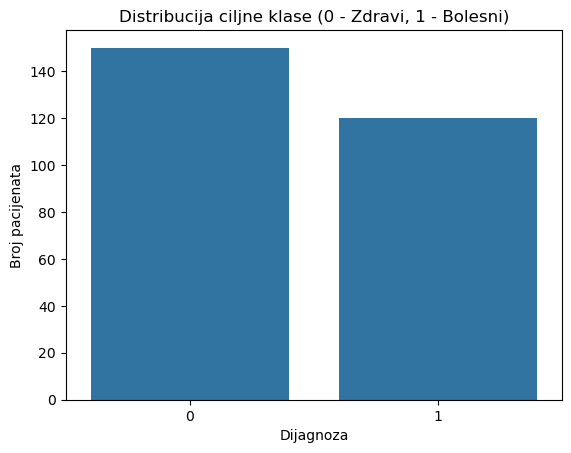

In [286]:
sns.countplot(x='Heart Disease', data=df)
plt.title('Distribucija ciljne klase (0 - Zdravi, 1 - Bolesni)')
plt.xlabel('Dijagnoza')
plt.ylabel('Broj pacijenata')
plt.show()

Analizom distribucije ciljne promenljive ustanovljeno je da su klase relativno balansirane. 

## Histogrami po klasama

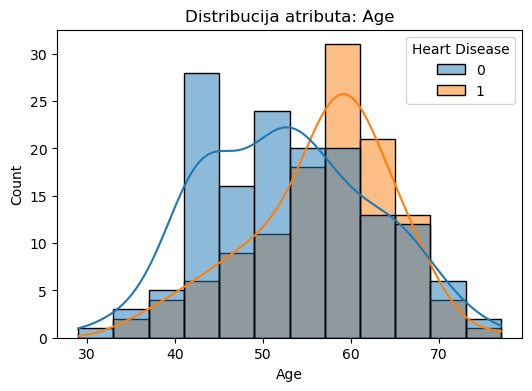

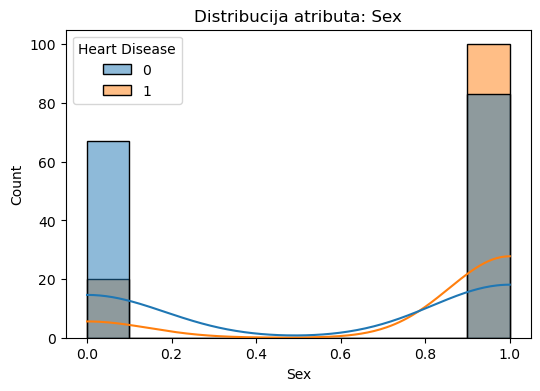

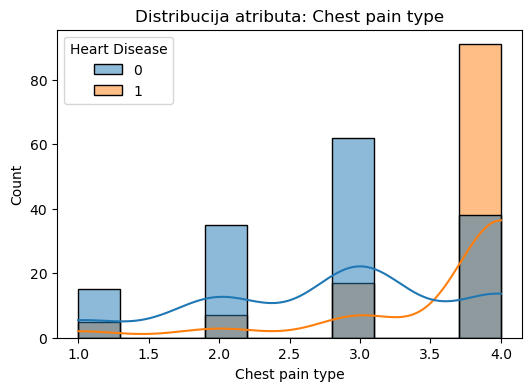

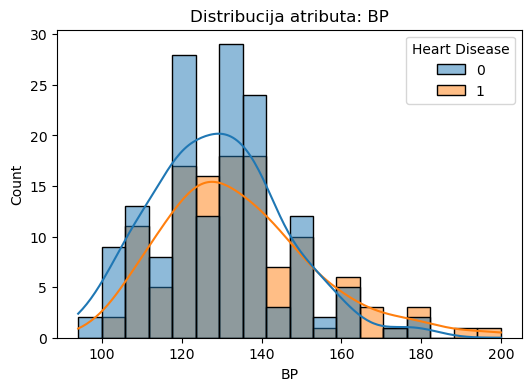

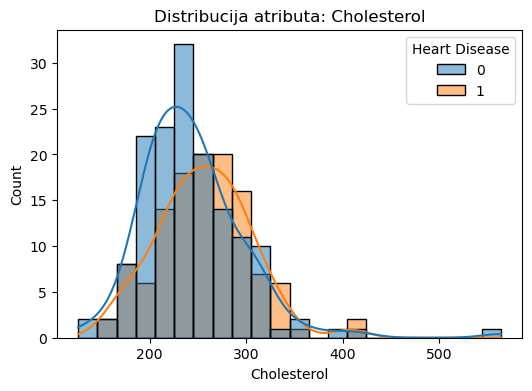

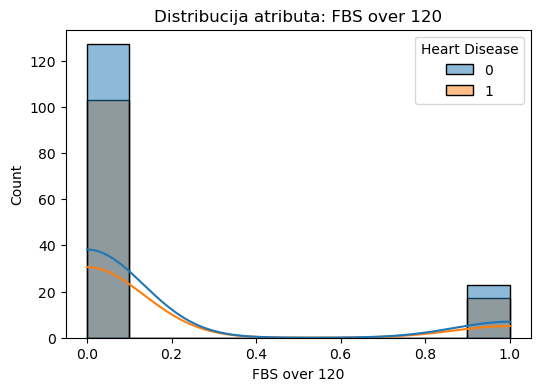

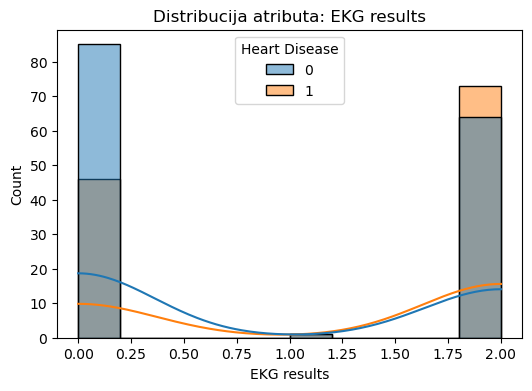

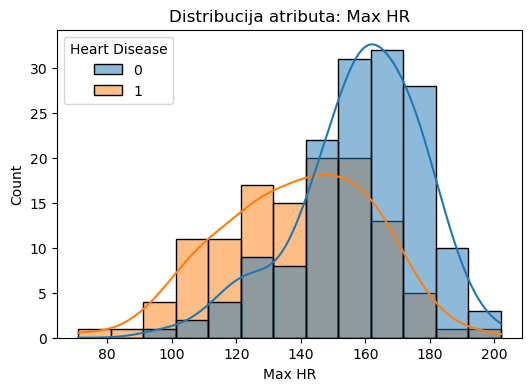

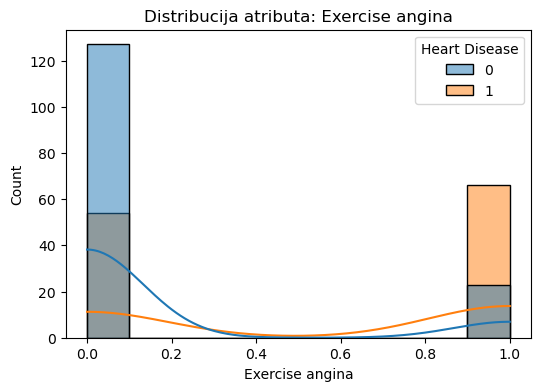

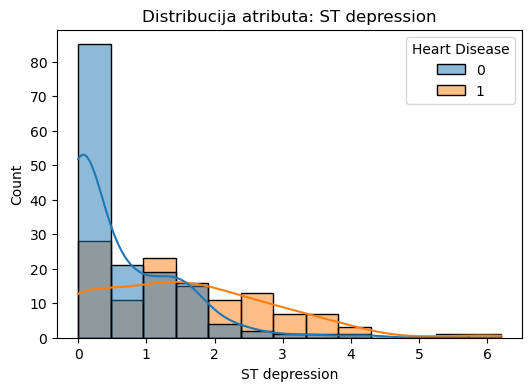

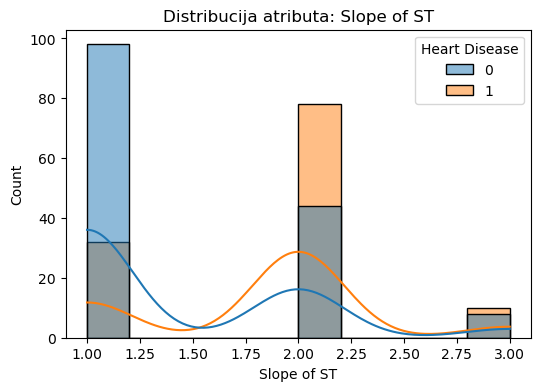

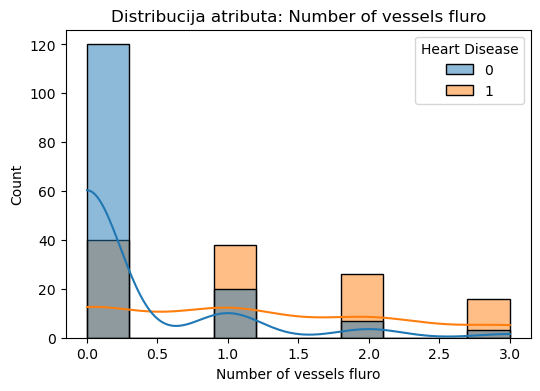

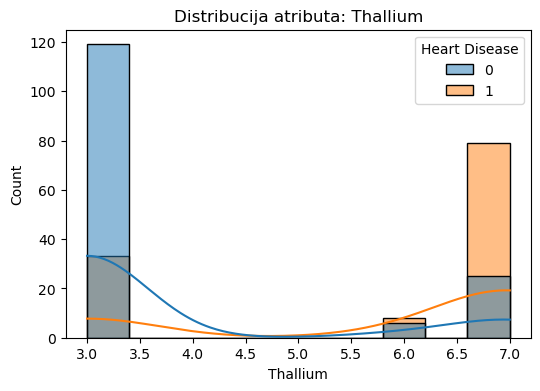

In [287]:
features = df.columns[:-1]

for col in features:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, hue="Heart Disease", kde=True)
    plt.title(f"Distribucija atributa: {col}")
    plt.show()


## Detekcija outliera

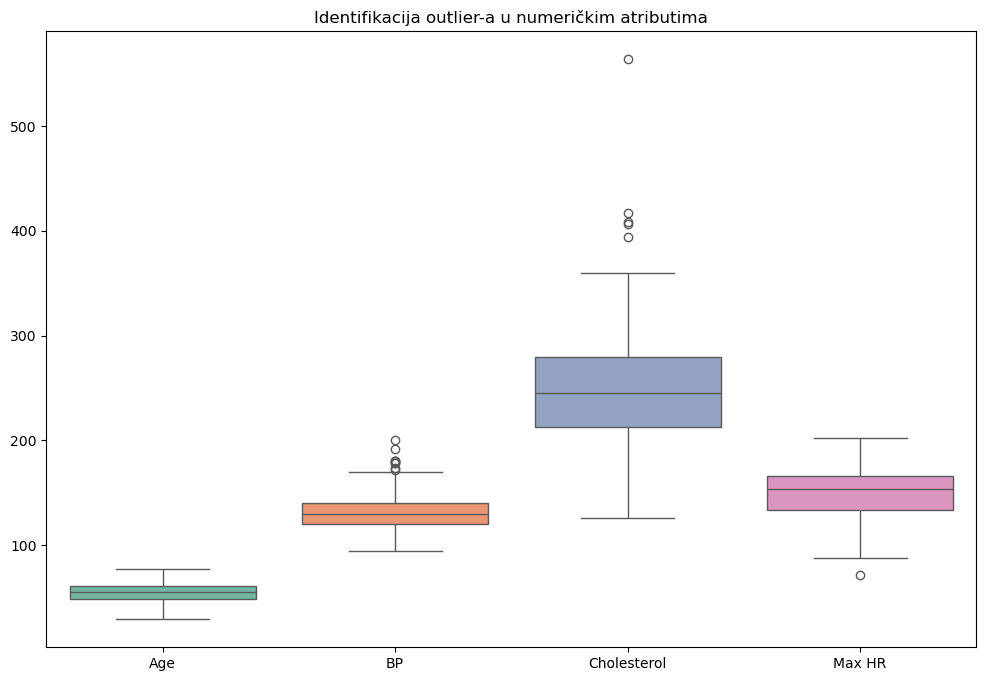

In [288]:
cols_to_check = ['Age', 'BP', 'Cholesterol', 'Max HR']

plt.figure(figsize=(12, 8))
sns.boxplot(data=df[cols_to_check], palette="Set2")
plt.title('Identifikacija outlier-a u numeričkim atributima')
plt.show()

## Matrica korelacije 

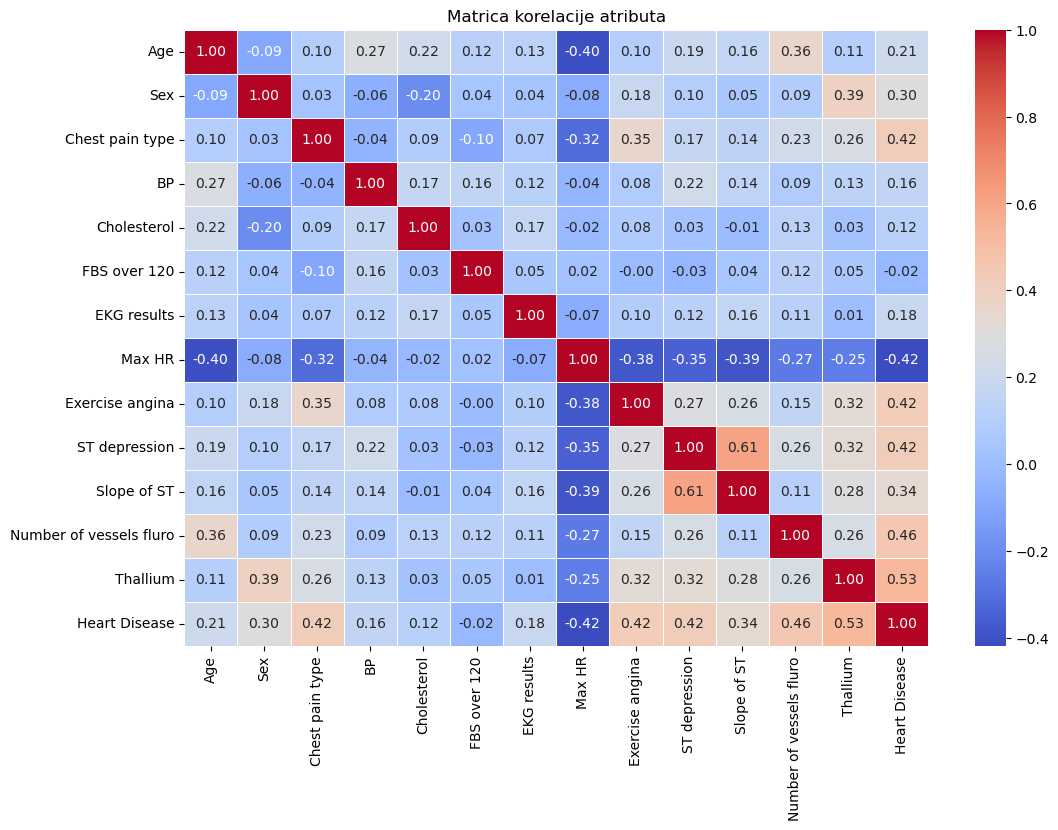

In [289]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matrica korelacije atributa')
plt.show()

## Podela na test i trening skup

In [290]:

X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Helper

In [291]:
def evaluate_model(model, X_test_data, y_test_true, name):
    y_pred = model.predict(X_test_data)
    
    metrics = {
        "Accuracy": accuracy_score(y_test_true, y_pred),
        "Precision": precision_score(y_test_true, y_pred),
        "Recall": recall_score(y_test_true, y_pred),
        "F1": f1_score(y_test_true, y_pred)
    }
    
    
    print(f"{name} Results")
    for key, value in metrics.items():
        print(f"{key}: {value:.4f}")
        
    plt.figure(figsize=(4, 3))
    cm = confusion_matrix(y_test_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    return metrics

### Baseline model

Baseline Results
Accuracy: 0.8889
Precision: 0.8571
Recall: 0.8571
F1: 0.8571


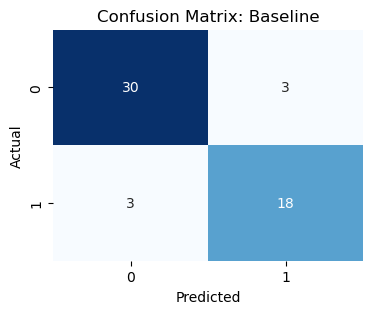

In [292]:
model = LogisticRegression(max_iter=1000,class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)


baseline_results = evaluate_model(model, X_test_scaled, y_test, "Baseline")

## Filter metode

### Chi-square selekcija 

In [293]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_mm = scaler.fit_transform(X_train)
X_test_mm = scaler.transform(X_test)


In [294]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(score_func=chi2, k=5)
X_train_filter = selector.fit_transform(X_train_mm, y_train)
X_test_filter = selector.transform(X_test_mm)

selected_features_filter = X.columns[selector.get_support()]
print("Chi-square atributi:", selected_features_filter)

Chi-square atributi: Index(['Exercise angina', 'ST depression', 'Slope of ST',
       'Number of vessels fluro', 'Thallium'],
      dtype='object')


Chi-square Results
Accuracy: 0.8333
Precision: 0.8333
Recall: 0.7143
F1: 0.7692


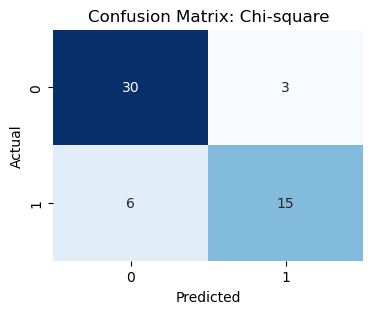

In [295]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_filter, y_train)


filter_results = evaluate_model(model, X_test_filter, y_test, "Chi-square")

### Mutal Information

In [296]:
from sklearn.feature_selection import mutual_info_classif

selector_mi = SelectKBest(score_func=mutual_info_classif, k=5)
X_train_mi = selector_mi.fit_transform(X_train_scaled, y_train)
X_test_mi = selector_mi.transform(X_test_scaled)

selected_features_mi = X.columns[selector_mi.get_support()]
print(f"Mutual Information odabrani atributi: {list(selected_features_mi)}")

Mutual Information odabrani atributi: ['Chest pain type', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


Mutual Info Results
Accuracy: 0.8519
Precision: 0.8421
Recall: 0.7619
F1: 0.8000


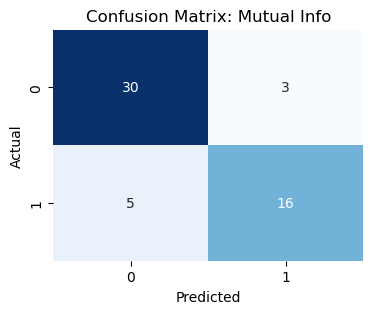

In [297]:
model_mi = LogisticRegression(max_iter=1000)
model_mi.fit(X_train_mi, y_train)

mi_results = evaluate_model(model_mi, X_test_mi, y_test, "Mutual Info")

## Wrapper metode

### RFE

In [298]:
from sklearn.feature_selection import RFE

rfe = RFE(model, n_features_to_select=5)
X_train_rfe = rfe.fit_transform(X_train_scaled, y_train)
X_test_rfe = rfe.transform(X_test_scaled)

selected_indices = rfe.get_support(indices=True)


selected_features = X.columns[selected_indices]
print(f"RFE odabrani atributi: {list(selected_features)}")

RFE odabrani atributi: ['Chest pain type', 'Exercise angina', 'ST depression', 'Number of vessels fluro', 'Thallium']


RFE Results
Accuracy: 0.9074
Precision: 1.0000
Recall: 0.7619
F1: 0.8649


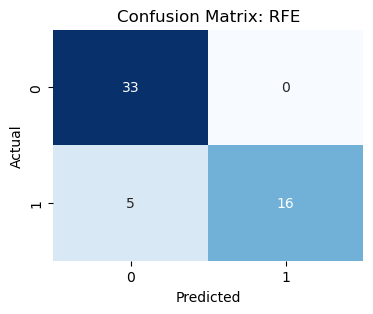

In [299]:
model.fit(X_train_rfe, y_train)

rfe_metrics = evaluate_model(model, X_test_rfe, y_test, "RFE")

### SFS

SFS odabrani atributi: ['Chest pain type', 'BP', 'ST depression', 'Number of vessels fluro', 'Thallium']
Forward Selection Results
Accuracy: 0.8519
Precision: 0.8421
Recall: 0.7619
F1: 0.8000


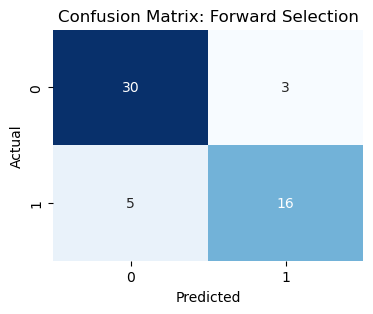

In [300]:
from sklearn.feature_selection import SequentialFeatureSelector

lr_wrapper = LogisticRegression(max_iter=1000)

sfs = SequentialFeatureSelector(lr_wrapper, n_features_to_select=5, direction='forward')
X_train_sfs = sfs.fit_transform(X_train_scaled, y_train)
X_test_sfs = sfs.transform(X_test_scaled)

selected_features_sfs = X.columns[sfs.get_support()]
print("SFS odabrani atributi:", list(selected_features_sfs))

lr_wrapper.fit(X_train_sfs, y_train)
sfs_results = evaluate_model(lr_wrapper, X_test_sfs, y_test, "Forward Selection")

## EMBEDDED

### Lasso

In [301]:
lasso_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=1000
)

lasso_model.fit(X_train_scaled, y_train)

selected_features_lasso = X.columns[lasso_model.coef_[0] != 0]
print("LASSO atributi:", selected_features_lasso)


LASSO atributi: Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium'],
      dtype='object')


Lasso Results
Accuracy: 0.9074
Precision: 0.9000
Recall: 0.8571
F1: 0.8780


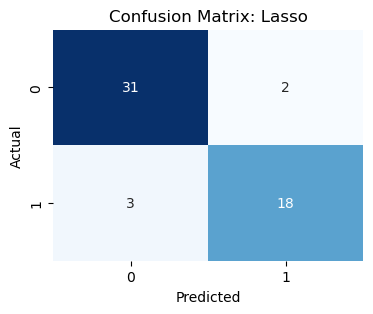

In [302]:
X_train_lasso = X_train_scaled[:, lasso_model.coef_[0] != 0]
X_test_lasso = X_test_scaled[:, lasso_model.coef_[0] != 0]

model.fit(X_train_lasso, y_train)

lasso_metrics = evaluate_model(model, X_test_lasso, y_test, "Lasso")

### Random forest

Random Forest Embedded atributi: ['Age', 'Chest pain type', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'Number of vessels fluro', 'Thallium']
RF Importance Results
Accuracy: 0.8333
Precision: 0.8750
Recall: 0.6667
F1: 0.7568


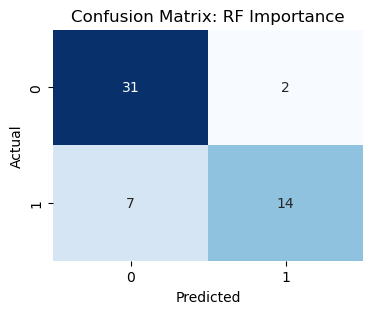

In [303]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_train, y_train)

embed_rf_selector = SelectFromModel(rf_selector, prefit=True)
X_train_rf = embed_rf_selector.transform(X_train_scaled)
X_test_rf = embed_rf_selector.transform(X_test_scaled)

selected_features_rf = X.columns[embed_rf_selector.get_support()]
print("Random Forest Embedded atributi:", list(selected_features_rf))

lr_rf = LogisticRegression(max_iter=1000)
lr_rf.fit(X_train_rf, y_train)
rf_embed_results = evaluate_model(lr_rf, X_test_rf, y_test, "RF Importance")

In [304]:

results = pd.DataFrame([
    baseline_results,
    filter_results,
    mi_results,
    rfe_metrics,
    sfs_results,
    lasso_metrics,
    rf_embed_results 
], index=["Baseline (Svi)", 
    "Filter (Chi2)", 
     "Filter (Mutual Info)",
    "Wrapper (RFE)", 
    "Wrapper (Forward)", 
    "Embedded (LASSO)", 
    "Embedded (RF)"])
results



,Accuracy,Precision,Recall,F1
Baseline (Svi),0.888889,0.857143,0.857143,0.857143
Filter (Chi2),0.833333,0.833333,0.714286,0.769231
Filter (Mutual Info),0.851852,0.842105,0.761905,0.800000
Wrapper (RFE),0.907407,1.000000,0.761905,0.864865
Wrapper (Forward),0.851852,0.842105,0.761905,0.800000
Embedded (LASSO),0.907407,0.900000,0.857143,0.878049
Embedded (RF),0.833333,0.875000,0.666667,0.756757


# Savremeni pristupi izbora atributa

## Povezanost LASSO i Sparse Learning pristupa

LASSO regularizacija predstavlja jedan od najpoznatijih primera Sparse Learning pristupa.

- LASSO koristi L1 regularizaciju
- ona forsira koeficijente manje važnih atributa ka nuli
- na taj način vrši implicitnu selekciju atributa

Sparse Learning može se posmatrati kao opšti okvir, dok je LASSO njegov najjednostavniji i najčešće korišćen predstavnik.


Napredni LASSO je zadržao samo 6 ključnih atributa.
Advanced LASSO Results
Accuracy: 0.8519
Precision: 0.8421
Recall: 0.7619
F1: 0.8000


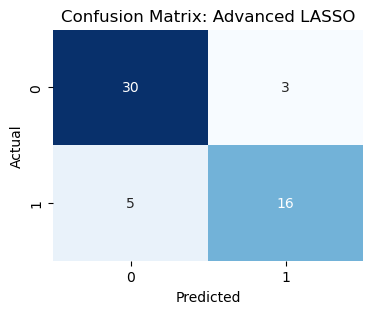

In [305]:
# Jača L1 regularizacija za postizanje Sparse strukture
advanced_lasso = LogisticRegression(
    penalty='l1', 
    solver='liblinear', 
    C=0.05,  # Manji C = strog kriterijum selekcije
    random_state=42
)
advanced_lasso.fit(X_train_scaled, y_train)

# Izdvajanje atributa koji su "preživeli" strog filter
sparse_features = X.columns[advanced_lasso.coef_[0] != 0]
print(f"Napredni LASSO je zadržao samo {len(sparse_features)} ključnih atributa.")
advanced_lasso_results = evaluate_model(advanced_lasso, X_test_scaled, y_test, "Advanced LASSO")

In [306]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': np.logspace(-3, 2, 20)  # od 0.001 do 100
}

lasso = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=1000,
    random_state=42
)

grid_search = GridSearchCV(
    lasso,
    param_grid,
    cv=5,
    scoring='f1',   
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Najbolji C:", grid_search.best_params_)
print("Najbolji F1:", grid_search.best_score_)
best_lasso = grid_search.best_estimator_

y_pred_best = best_lasso.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1:", f1_score(y_test, y_pred_best))

lasso_optimized_results = {
    'Accuracy': accuracy_score(y_test, y_pred_best),
    'Precision': precision_score(y_test, y_pred_best),
    'Recall': recall_score(y_test, y_pred_best),
    'F1': f1_score(y_test, y_pred_best)
}

Najbolji C: {'C': np.float64(0.42813323987193913)}
Najbolji F1: 0.8049510179742739
Accuracy: 0.9074074074074074
Precision: 0.9
Recall: 0.8571428571428571
F1: 0.8780487804878049


U cilju određivanja optimalnog stepena regularizacije primenjen je GridSearchCV postupak nad L1 logističkom regresijom. Parametar C variran je u logaritamskom opsegu, pri čemu je optimalna vrednost iznosila C = 0.428. Za razliku od agresivnije regularizacije (C = 0.05), koja je dovela do pada performansi, optimalna vrednost C omogućila je eliminaciju manje značajnih atributa uz zadržavanje stabilnih performansi. Ovi rezultati potvrđuju efikasnost sparse pristupa u kontekstu izbora atributa.

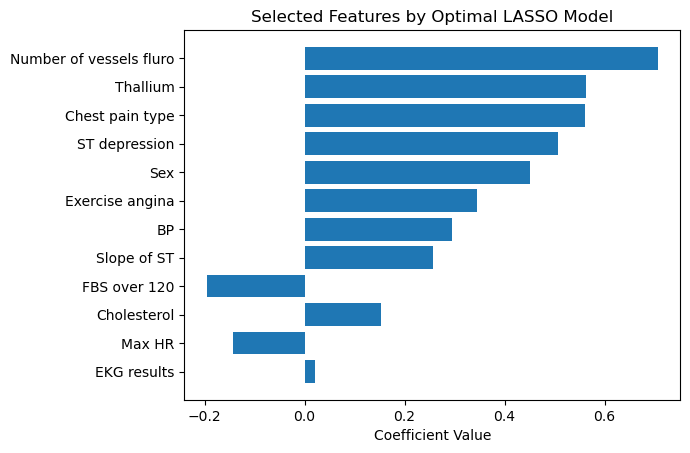

Broj izabranih atributa: 12


In [307]:
best_model = grid_search.best_estimator_

coefficients = best_model.coef_[0]

feature_names = X.columns

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

selected_features = coef_df[coef_df["Coefficient"] != 0]

selected_features = selected_features.reindex(
    selected_features["Coefficient"].abs().sort_values(ascending=True).index
)

plt.figure()
plt.barh(selected_features["Feature"], selected_features["Coefficient"])
plt.xlabel("Coefficient Value")
plt.title("Selected Features by Optimal LASSO Model")
plt.show()

print("Broj izabranih atributa:", len(selected_features))


Iako je cilj LASSO metode postizanje sparsnosti (retkosti), naš optimizovani model je zadržao 12 od 13 atributa uz postizanje maksimalne tačnosti od 90.74%. Ovo ukazuje na to da su izabrani medicinski parametri visoko informativni i međusobno komplementarni. Model je uspešno identifikovao i eliminisao samo jedan statistički beznačajan atribut, čime je postignut idealan balans između kompleksnosti i preciznosti.“

## Duboko učenje i nelinearna selekcija atributa 

Dok je LASSO linearni model, neuronska mreža može da identifikuje nelinearne zavisnosti između medicinskih faktora. Koristimo L1 regularizaciju direktno na ulaznom sloju mreže.

In [308]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers, Input

dl_model = tf.keras.Sequential([
    Input(shape=(X_train_scaled.shape[1],)), 
    
    # Prvi sloj sa L1 regularizacijom za selekciju atributa
    layers.Dense(16, activation='relu', 
                 kernel_regularizer=regularizers.l1(0.01)),
    
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

dl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

dl_model.fit(X_train_scaled, y_train, epochs=100, batch_size=16, verbose=0, 
                    validation_data=(X_test_scaled, y_test))


Važnost atributa (Deep Learning FS via MLP):
BP                         0.428581
Cholesterol                0.406280
Age                        0.403747
Chest pain type            0.390750
Number of vessels fluro    0.384520
ST depression              0.367158
Max HR                     0.360548
Slope of ST                0.345439
Exercise angina            0.337382
Thallium                   0.328316
FBS over 120               0.311590
Sex                        0.293973
EKG results                0.236473
dtype: float64


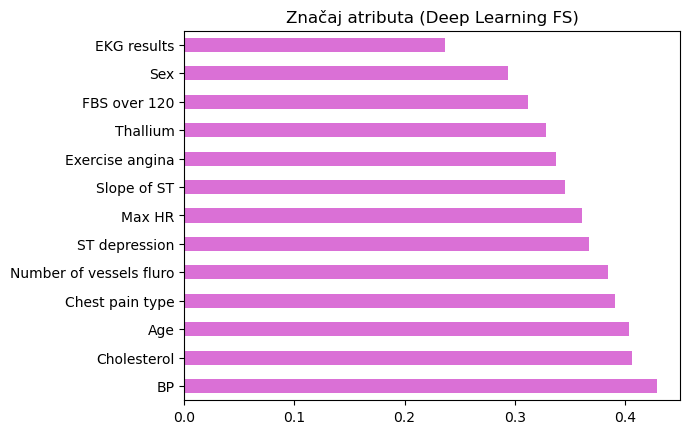

In [309]:
from sklearn.neural_network import MLPClassifier

# Neuronska mreža sa L1 regularizacijom 
mlp_fs = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=1500, random_state=42)
mlp_fs.fit(X_train_scaled, y_train)

dl_importance = np.mean(np.abs(mlp_fs.coefs_[0]), axis=1)
dl_feature_importance = pd.Series(dl_importance, index=X.columns).sort_values(ascending=False)

print("Važnost atributa (Deep Learning FS via MLP):")
print(dl_feature_importance)

dl_feature_importance.plot(kind='barh', color='orchid')
plt.title('Značaj atributa (Deep Learning FS)')
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
Deep Learning FS Metrike:
-------------------------
Accuracy:  0.8148
Precision: 0.8667
Recall:    0.6190
F1 Score:  0.7222



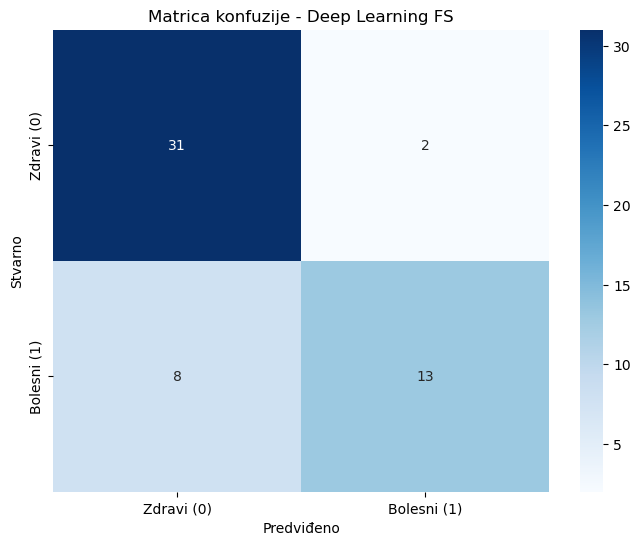

In [310]:
y_pred_probs = dl_model.predict(X_test_scaled)

y_pred = (y_pred_probs > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Deep Learning FS Metrike:\n" + "-"*25)
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}\n")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Zdravi (0)', 'Bolesni (1)'], 
            yticklabels=['Zdravi (0)', 'Bolesni (1)'])
plt.xlabel('Predviđeno')
plt.ylabel('Stvarno')
plt.title('Matrica konfuzije - Deep Learning FS')
plt.show()

Primetna je razlika u sparsnosti (retkosti) modela: dok je Advanced Lasso izvršio strogu selekciju i eliminisao 7 od 13 atributa, Deep Learning FS je zadržao sve atribute ali sa različitim nivoima važnosti. Ovo potvrđuje teoriju da duboko učenje teži da zadrži širi kontekst informacija radi prepoznavanja nelinearnih obrazaca, dok Lasso teži ka maksimalnoj jednostavnosti i interpretabilnosti modela.

## Causal Feature Selection

Tradicionalne metode selekcije atributa uglavnom se oslanjaju na statističku zavisnost između atributa i ciljne promenljive. Međutim, visoka korelacija ne garantuje da je određeni atribut stvarni uzrok posmatranog ishoda. Zbog toga je u ovom delu projekta primenjen pristup selekcije atributa koji kombinuje više različitih metoda kako bi se identifikovali stabilni i potencijalno uzročni faktori.

Osnovna ideja je da se atributi mogu smatrati kauzalno relevantnim ukoliko se dosledno pojavljuju kao važni kroz različite, međusobno nezavisne pristupe selekciji. U tu svrhu korišćene su dve komplementarne metode:

- Sparse Learning pristup zasnovan na LASSO regularizaciji, koji vrši selekciju atributa eliminacijom koeficijenata male važnosti,
- Feature importance dobijen iz Deep Learning modela, koji identifikuje atribute sa najvećim doprinosom predikciji.

Nakon identifikacije ovih atributa, treniran je finalni logistički regresioni model i evaluiran korišćenjem standardnih metrika: tačnosti, preciznosti, odziva i F1 mere.

Uzročni atributi identifikovani kroz stabilnost: ['Chest pain type', 'Max HR', 'Cholesterol', 'Thallium', 'Age', 'ST depression', 'BP', 'Exercise angina', 'Number of vessels fluro']
REZULTATI: CAUSAL FEATURE SELECTION
-----------------------------------
Accuracy:  0.8889
Precision: 1.0000
Recall:    0.7143
F1 Score:  0.8333
-----------------------------------


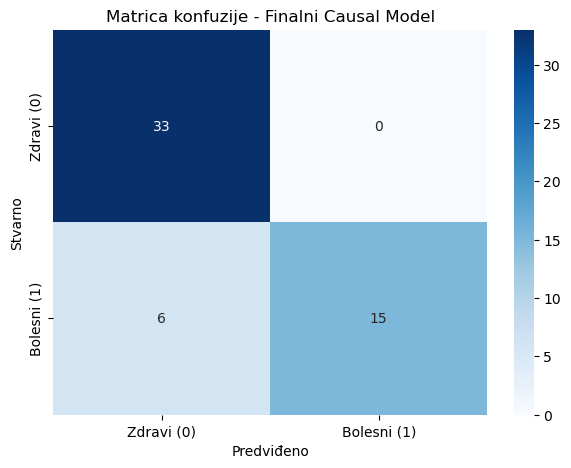

In [311]:
# Pronalaženje zajedničkih atributa 
lasso_features = set(sparse_features) # Atributi iz Lasso-a
dl_features = set(dl_feature_importance.nlargest(6).index) # Top 6 iz Deep Learning-a

causal_features = list(lasso_features.union(dl_features))

print(f"Uzročni atributi identifikovani kroz stabilnost: {causal_features}")

X_train_c = pd.DataFrame(X_train_scaled, columns=X.columns)[causal_features]
X_test_c = pd.DataFrame(X_test_scaled, columns=X.columns)[causal_features]

final_model = LogisticRegression()
final_model.fit(X_train_c, y_train)

y_pred_final = final_model.predict(X_test_c)
accuracy = accuracy_score(y_test, y_pred_final)
precision = precision_score(y_test, y_pred_final)
recall = recall_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)

print("REZULTATI: CAUSAL FEATURE SELECTION")
print("-" * 35)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("-" * 35)

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Zdravi (0)', 'Bolesni (1)'], 
            yticklabels=['Zdravi (0)', 'Bolesni (1)'])
plt.title('Matrica konfuzije - Finalni Causal Model')
plt.xlabel('Predviđeno')
plt.ylabel('Stvarno')
plt.show()

## Causal selekcija zasnovana na Markov Blanket konceptu

Drugi pristup kauzalnoj selekciji atributa zasnovan je na konceptu Markov Blanket-a.  
Markov Blanket predstavlja minimalni skup atributa koji sadrži sve potrebne informacije za predikciju ciljne promenljive. Atributi izvan ovog skupa smatraju se uslovno nezavisnim od cilja i stoga ne doprinose predikciji.

Markov Blanket je određen učenjem strukture Bayesove mreže pomoću Hill Climb algoritma uz BIC kriterijum. Nakon diskretizacije numeričkih atributa, identifikovani su roditelji, potomci i supružnici ciljne promenljive, čime je definisan minimalni skup atributa koji zadržava sve informacione zavisnosti prema ciljnoj klasi.

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Age': 'N', 'Sex': 'N', 'Chest pain type': 'N', 'BP': 'N', 'Cholesterol': 'N', 'FBS over 120': 'N', 'EKG results': 'N', 'Max HR': 'N', 'Exercise angina': 'N', 'ST depression': 'N', 'Slope of ST': 'N', 'Number of vessels fluro': 'N', 'Thallium': 'N', 'Heart Disease': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Age': 'N', 'Sex': 'N', 'Chest pain type': 'N', 'BP': 'N', 'Cholesterol': 'N', 'FBS over 120': 'N', 'EKG results': 'N', 'Max HR': 'N', 'Exercise angina': 'N', 'ST depression': 'N', 'Slope of ST': 'N', 'Number of vessels fluro': 'N', 'Thallium': 'N', 'Heart Disease': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Age': 'N', 'Sex': 'N', 'Chest pain type': 'N', 'BP': 'N', 'Cholesterol': 'N', 'FBS over 120': 'N', 'EKG results': 'N', 'Max HR': 'N', 'Ex

  0%|          | 0/1000000 [00:00<?, ?it/s]

Izabrani atributi: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol']

 REZULTATI ZA BAYES MB 
Accuracy  : 0.7778
Precision : 0.7143
Recall    : 0.7143
F1        : 0.7143


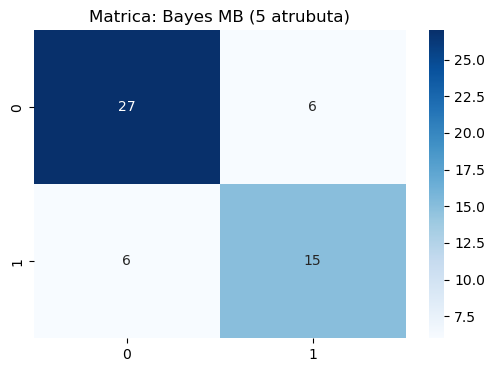

In [313]:
import networkx as nx
from pgmpy.estimators import HillClimbSearch
from pgmpy.models import DiscreteBayesianNetwork

target_col = 'num' if 'num' in df.columns else 'target'

hc = HillClimbSearch(df)
best_model_structure = hc.estimate(scoring_method='k2')
model = DiscreteBayesianNetwork(best_model_structure.edges())
model.add_nodes_from(df.columns)

try:
    mb_features = list(model.get_markov_blanket(target_col))
    if not mb_features:
        mb_features = df.corr()[target_col].abs().sort_values(ascending=False).index[1:6].tolist()
except:
    mb_features = df.columns[:5].tolist()

print(f"Izabrani atributi: {mb_features}")

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

X_train_mb = X_train_scaled_df[mb_features]
X_test_mb = X_test_scaled_df[mb_features]

mb_classifier = LogisticRegression(random_state=42)
mb_classifier.fit(X_train_mb, y_train)
y_pred_mb = mb_classifier.predict(X_test_mb)

mb_results = {
    'Accuracy': accuracy_score(y_test, y_pred_mb),
    'Precision': precision_score(y_test, y_pred_mb),
    'Recall': recall_score(y_test, y_pred_mb),
    'F1': f1_score(y_test, y_pred_mb)
}

print("\n" + "="*30)
print(" REZULTATI ZA BAYES MB ")
print("="*30)
for k, v in mb_results.items():
    print(f"{k:10}: {v:.4f}")
print("="*30)

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_mb), annot=True, fmt='d', cmap='Blues')
plt.title(f'Matrica: Bayes MB ({len(mb_features)} atrubuta)')
plt.show()

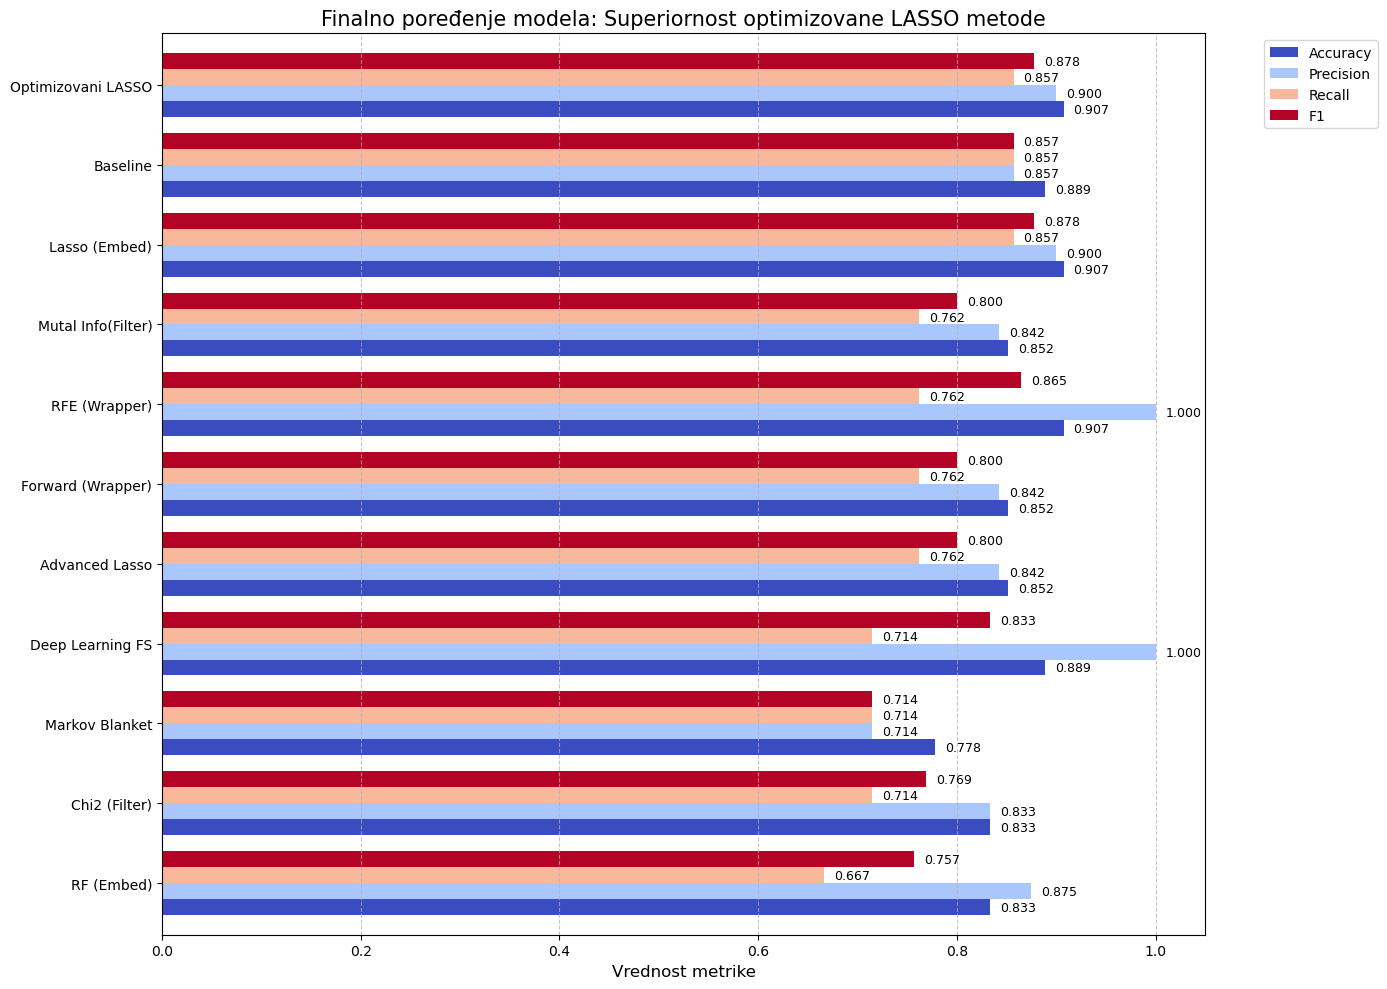

In [315]:
dl_fs_results = {
    'Accuracy': 0.8889, 
    'Precision': 1.0000, 
    'Recall': 0.7143, 
    'F1': 0.8333
}
final_comparison = pd.DataFrame([
    baseline_results,
    filter_results,
    mi_results,         
    rfe_metrics,
    sfs_results,
    lasso_metrics,
    rf_embed_results,
    advanced_lasso_results,   
    dl_fs_results,       
    mb_results,          
    lasso_optimized_results  
], index=[
     "Baseline", "Chi2 (Filter)","Mutal Info(Filter)", "RFE (Wrapper)", 

    "Forward (Wrapper)", "Lasso (Embed)", "RF (Embed)" ,
    "Advanced Lasso", 
    "Deep Learning FS", 
    "Markov Blanket",
    "Optimizovani LASSO"
])

final_comparison = final_comparison.sort_values(by="Recall", ascending=True)

ax = final_comparison.plot(kind='barh', figsize=(14, 10), width=0.8, colormap='coolwarm')
plt.title('Finalno poređenje modela: Superiornost optimizovane LASSO metode', fontsize=15)
plt.xlabel('Vrednost metrike', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.7)

for p in ax.patches:
    ax.annotate(f"{p.get_width():.3f}", (p.get_width() + 0.01, p.get_y() + 0.05), fontsize=9)

plt.tight_layout()
plt.show()